In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

# Loading cleaned reviews
df = pd.read_csv('/content/drive/MyDrive/game_reviews_cleaned.csv')
df['date_posted'] = pd.to_datetime(df['date_posted'])

# Loading the signals table (optional, we'll recompute some for consistency)
signals = pd.read_csv('/content/drive/MyDrive/game_acquisition_signals.csv')

In [10]:
!pip install textblob
!python -m textblob.download_corpora


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [11]:
from textblob import TextBlob

In [15]:
if 'review' in df.columns and 'sentiment_polarity' not in df.columns:
    print("Computing sentiment polarity from review text...")
    df['sentiment_polarity'] = df['review'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
elif 'sentiment_polarity' not in df.columns:
    print("Review column missing. Setting sentiment_polarity to 0 (neutral).")
    df['sentiment_polarity'] = 0.0
else:
    print("sentiment_polarity already present")

Review column missing. Setting sentiment_polarity to 0 (neutral).


In [16]:
# For each game, compute these four components
game_target = []

for title in df['title'].unique():
    sub = df[df['title'] == title].sort_values('date_posted')

    # 1. High hours
    high_hours = (sub['hour_played'].median() > 20)

    # 2. Consistent rec rate
    if len(sub) > 100:
        first_half = sub.head(len(sub)//2)['is_recommended'].mean()
        second_half = sub.tail(len(sub)//2)['is_recommended'].mean()
        consistent_rec = (second_half > 0.75) and (first_half - second_half < 0.1)
    else:
        consistent_rec = (sub['is_recommended'].mean() > 0.75)

    # 3. Helpful votes above median
    helpful_above_median = (sub['helpful'].mean() > df['helpful'].median())

    # 4. Volume decay (need at least 12 weeks of data)
    if (sub['date_posted'].max() - sub['date_posted'].min()).days > 90:
        weekly_vol = sub.set_index('date_posted').resample('W').size()
        if len(weekly_vol) >= 12:
            slope = np.polyfit(range(len(weekly_vol)), weekly_vol.values, 1)[0]
            low_decay = (slope > -0.1)
        else:
            low_decay = False
    else:
        low_decay = False  # not enough history – penalize

    score = sum([high_hours, consistent_rec, helpful_above_median, low_decay])
    game_target.append({
        'title': title,
        'long_term_score': score,
        'is_long_term_value': score >= 3
    })

target_df = pd.DataFrame(game_target)
target_df

,title,long_term_score,is_long_term_value
0,Rust,3,True
1,Euro Truck Simulator 2,4,True
2,Dead by Daylight,3,True
3,Grand Theft Auto V,3,True
4,MONSTER HUNTER: WORLD,2,False
5,ASTRONEER,4,True
6,PLAYERUNKNOWN'S BATTLEGROUNDS,2,False
7,Left 4 Dead 2,4,True
8,Rocket League®,3,True
9,RESIDENT EVIL 2 / BIOHAZARD RE:2,3,True


In [18]:
# Group by game title and aggregate all numeric/categorical features
game_features = df.groupby('title').agg(
    n_reviews = ('title', 'count'),                     # count rows per game
    rec_rate = ('is_recommended', 'mean'),
    median_hours = ('hour_played', 'median'),
    mean_helpful = ('helpful', 'mean'),
    mean_funny = ('funny', 'mean'),
    pct_early_access = ('is_early_access_review', 'mean'),
    review_len_mean = ('review_len', 'mean'),
    review_len_std = ('review_len', 'std'),
    sentiment_mean = ('sentiment_polarity', 'mean')
).reset_index()

In [19]:
# Add lifetime days and rec_trend for each game
for title in df['title'].unique():
    sub = df[df['title'] == title].sort_values('date_posted')
    lifetime = (sub['date_posted'].max() - sub['date_posted'].min()).days
    # rec_trend = difference between last 30% and first 30% recommendation rate
    n = len(sub)
    first_rec = sub.head(max(1, int(0.3*n)))['is_recommended'].mean()
    last_rec = sub.tail(max(1, int(0.3*n)))['is_recommended'].mean()
    rec_trend = last_rec - first_rec

    game_features.loc[game_features['title'] == title, 'lifetime_days'] = lifetime
    game_features.loc[game_features['title'] == title, 'rec_trend'] = rec_trend

game_features.head()

,title,n_reviews,rec_rate,median_hours,mean_helpful,mean_funny,pct_early_access,review_len_mean,review_len_std,sentiment_mean,lifetime_days,rec_trend
0,ACE COMBAT™ 7: SKIES UNKNOWN,8,1.000000,25.5,295.250000,28.125000,0.000000,944.750000,1150.435290,0.0,5.0,0.000000
1,ASTRONEER,576,0.861111,28.0,9.223958,0.897569,0.921875,354.756944,607.218064,0.0,790.0,0.029070
2,Beat Saber,10,1.000000,26.5,230.000000,89.200000,1.000000,637.300000,1000.288964,0.0,234.0,0.000000
3,Dead by Daylight,1034,0.630561,97.0,0.193424,0.125725,0.000000,275.081238,528.067473,0.0,970.0,0.087097
4,Euro Truck Simulator 2,330,1.000000,96.0,6.566667,1.160606,0.000000,207.433333,408.586462,0.0,1621.0,0.000000


In [25]:
game_target = []

for title in df['title'].unique():
    sub = df[df['title'] == title].sort_values('date_posted')

    # 1. High hours
    high_hours = (sub['hour_played'].median() > 20)

    # 2. Consistent rec rate
    if len(sub) > 100:
        first_half = sub.head(len(sub)//2)['is_recommended'].mean()
        second_half = sub.tail(len(sub)//2)['is_recommended'].mean()
        consistent_rec = (second_half > 0.75) and (first_half - second_half < 0.1)
    else:
        consistent_rec = (sub['is_recommended'].mean() > 0.75)

    # 3. Helpful votes above median
    helpful_above_median = (sub['helpful'].mean() > df['helpful'].median())

    # 4. Volume decay (need at least 12 weeks)
    if (sub['date_posted'].max() - sub['date_posted'].min()).days > 90:
        weekly_vol = sub.set_index('date_posted').resample('W').size()
        if len(weekly_vol) >= 12:
            slope = np.polyfit(range(len(weekly_vol)), weekly_vol.values, 1)[0]
            low_decay = (slope > -0.1)
        else:
            low_decay = False
    else:
        low_decay = False

    score = sum([high_hours, consistent_rec, helpful_above_median, low_decay])
    game_target.append({
        'title': title,
        'long_term_score': score,
        'is_long_term_value': score >= 3
    })

target_df = pd.DataFrame(game_target)

# Merge target into game_features
game_features = game_features.merge(target_df, on='title')

In [26]:
import numpy as np

def calculate_acquisition_score(row):
    """
    Weighted score: 30% Demand, 40% Satisfaction, 30% Resilience
    Returns score 0-100
    """
    # Demand (30%)
    # Normalized review volume (log scale)
    max_reviews = game_features['n_reviews'].max()
    volume_score = np.log1p(row['n_reviews']) / np.log1p(max_reviews) if max_reviews > 0 else 0

    # Normalized helpful votes (cap at 10 helpful average)
    helpful_score = min(row['mean_helpful'] / 10, 1)

    # Combine demand components (equal weight within demand)
    demand = (volume_score * 0.5 + helpful_score * 0.5) * 100

    # Satisfaction (40%)
    # Recommendation rate (0-1 scale)
    rec_component = row['rec_rate']

    # Median hours played (cap at 50 hours for full score)
    hours_component = min(row['median_hours'] / 50, 1)

    # Sentiment polarity mapped from [-1,1] to [0,1]
    sentiment_component = (row['sentiment_mean'] + 1) / 2

    satisfaction = (rec_component * 0.5 +
                    hours_component * 0.25 +
                    sentiment_component * 0.25) * 100

    # Resilience (30%)
    if row['lifetime_days'] > 90:
        # rec_trend is difference (last 30% - first 30%)
        # Positive or small negative is good; large negative bad
        trend_score = max(0, 1 + row['rec_trend'])  # if rec_trend = -0.2 -> 0.8; if -0.5 -> 0.5
        trend_score = min(trend_score, 1)  # cap at 1
    else:
        # Not enough history → neutral/punitive
        trend_score = 0.4

    # Also consider early access effect (if many EA reviews, assume more risk)
    ea_penalty = 1 - min(row['pct_early_access'], 0.5)  # up to 50% penalty if 100% EA

    resilience = trend_score * 100 * ea_penalty

    # Weighted total
    total = 0.3 * demand + 0.4 * satisfaction + 0.3 * resilience
    return total

# Apply scoring
game_features['acquisition_score'] = game_features.apply(calculate_acquisition_score, axis=1)

# Rank games
game_features_sorted = game_features.sort_values('acquisition_score', ascending=False)
print(game_features_sorted[['title', 'acquisition_score', 'is_long_term_value', 'rec_rate', 'median_hours']])

                                          title  acquisition_score  \
20                                     Terraria          90.486551   
9                                 Left 4 Dead 2          90.067178   
18                               Stardew Valley          89.978159   
4                        Euro Truck Simulator 2          85.951664   
19                                   Subnautica          84.155535   
21  The Elder Scrolls V: Skyrim Special Edition          78.104377   
11                                Overcooked! 2          76.588087   
14                                     RimWorld          74.988530   
5                                      Factorio          74.698745   
17                               Slay the Spire          74.664109   
7                            Grand Theft Auto V          72.090504   
3                              Dead by Daylight          71.184345   
10                        MONSTER HUNTER: WORLD          70.653881   
15                  

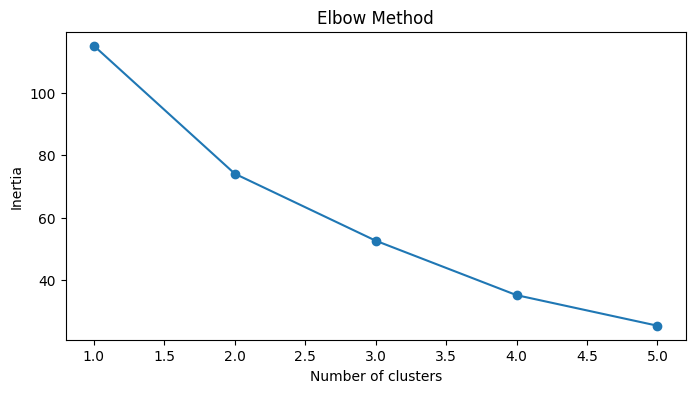

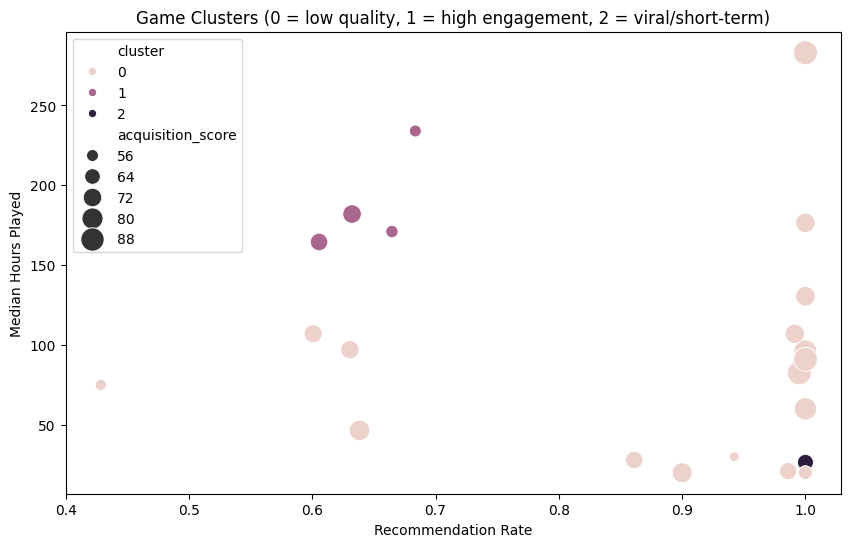

         rec_rate  median_hours  mean_helpful    n_reviews  rec_trend  \
cluster                                                                 
0        0.880819     86.529412     23.152948   342.294118   0.038858   
1        0.646519    187.875000      0.315289  2193.250000  -0.109481   
2        1.000000     26.000000    262.625000     9.000000   0.000000   

         sentiment_mean  acquisition_score  
cluster                                     
0                   0.0          74.396381  
1                   0.0          63.507256  
2                   0.0          63.096108  


In [27]:
# Select features for clustering (exclude target and identifiers)
cluster_features = ['rec_rate', 'median_hours', 'mean_helpful', 'n_reviews', 'rec_trend', 'sentiment_mean']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(game_features[cluster_features])

# Determine optimal clusters with elbow method (optional)
inertias = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,6), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Choose k=3 (assuming elbow at 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
game_features['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=game_features, x='rec_rate', y='median_hours',
                hue='cluster', size='acquisition_score', sizes=(50,300))
plt.title('Game Clusters (0 = low quality, 1 = high engagement, 2 = viral/short-term)')
plt.xlabel('Recommendation Rate')
plt.ylabel('Median Hours Played')
plt.show()

# Interpret each cluster by its average features
cluster_summary = game_features.groupby('cluster')[cluster_features + ['acquisition_score']].mean()
print(cluster_summary)

# Final Acquisition Recommendation Table

In [29]:
# Define thresholds from EDA signals
game_features['recommendation'] = 'Pass'
game_features.loc[game_features['acquisition_score'] >= 70, 'recommendation'] = 'Acquire'
game_features.loc[(game_features['acquisition_score'] >= 50) & (game_features['acquisition_score'] < 70), 'recommendation'] = 'Monitor'

# Short-term buzz flag: use same rules as EDA risk_category
game_features['risk_flag'] = 'Stable'
game_features.loc[(game_features['n_reviews'] > 500) &
                  (game_features['median_hours'] < 10) &
                  (game_features['rec_trend'] < -0.1), 'risk_flag'] = 'Short-term Buzz'

# Low risk flag (long-term value)
game_features.loc[(game_features['rec_rate'] > 0.8) &
                  (game_features['median_hours'] > 20) &
                  (game_features['rec_trend'] > -0.05), 'risk_flag'] = 'Long-term Value'

# Final output
final_cols = ['title', 'acquisition_score', 'rec_rate', 'median_hours',
              'rec_trend', 'risk_flag', 'recommendation']
final_table = game_features[final_cols].sort_values('acquisition_score', ascending=False)

print(final_table.to_string(index=False))

final_table.to_csv('/content/drive/MyDrive/acquisition_recommendations.csv', index=False)

                                      title  acquisition_score  rec_rate  median_hours  rec_trend       risk_flag recommendation
                                   Terraria          90.486551  1.000000         283.0   0.000000 Long-term Value        Acquire
                              Left 4 Dead 2          90.067178  0.995050          82.5   0.016667 Long-term Value        Acquire
                             Stardew Valley          89.978159  1.000000          91.0   0.000000 Long-term Value        Acquire
                     Euro Truck Simulator 2          85.951664  1.000000          96.0   0.000000 Long-term Value        Acquire
                                 Subnautica          84.155535  1.000000          60.0   0.000000 Long-term Value        Acquire
The Elder Scrolls V: Skyrim Special Edition          78.104377  0.638320          46.5  -0.061644          Stable        Acquire
                              Overcooked! 2          76.588087  0.900000          20.0   0.333333

In [30]:
# Create binary target: 1 = "Acquire", 0 = "Monitor" or "Pass"
recommendation_map = final_table.set_index('title')['recommendation'].to_dict()
df['target'] = df['title'].map(lambda x: 1 if recommendation_map.get(x) == 'Acquire' else 0)

print(f"Target distribution:\n{df['target'].value_counts()}")
print(f"Acquire games: {df[df['target']==1]['title'].unique()}")

Target distribution:
target
0    7912
1    6698
Name: count, dtype: int64
Acquire games: ['Euro Truck Simulator 2' 'Dead by Daylight' 'Grand Theft Auto V'
 'MONSTER HUNTER: WORLD' 'Left 4 Dead 2'
 'The Elder Scrolls V: Skyrim Special Edition' 'Subnautica' 'Factorio'
 'Slay the Spire' 'Stardew Valley' 'Terraria' 'RimWorld' 'Overcooked! 2']


In [31]:
# Sort by date and split: first 80% of reviews by time for training, last 20% for testing
df_sorted = df.sort_values('date_posted')
split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx]
test_df = df_sorted.iloc[split_idx:]

print(f"Train: {len(train_df)} reviews, Test: {len(test_df)} reviews")

Train: 11688 reviews, Test: 2922 reviews


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

# Prepare numeric features only
numeric_features = ['hour_played', 'helpful', 'funny', 'is_early_access_review',
                    'review_len', 'sentiment_polarity']

# Time-based split
df_sorted = df.sort_values('date_posted')
split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx]
test_df = df_sorted.iloc[split_idx:]

X_train = train_df[numeric_features]
y_train = train_df['target']
X_test = test_df[numeric_features]
y_test = test_df['target']

# Scale features
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")

# Feature importance (coefficients after scaling)
coefs = model.named_steps['clf'].coef_[0]
feature_importance = pd.DataFrame({'feature': numeric_features, 'coefficient': coefs})
feature_importance = feature_importance.sort_values('coefficient', ascending=False)
print("\nFeature importance (positive = predicts Acquire):")
print(feature_importance)

# Save model
import joblib
joblib.dump(model, 'acquisition_model_numeric.pkl')

              precision    recall  f1-score   support

           0       0.40      0.10      0.16      1541
           1       0.45      0.83      0.59      1381

    accuracy                           0.45      2922
   macro avg       0.43      0.47      0.37      2922
weighted avg       0.42      0.45      0.36      2922

ROC AUC: 0.424

Feature importance (positive = predicts Acquire):
                  feature  coefficient
1                 helpful     0.419256
4              review_len     0.150572
5      sentiment_polarity     0.000000
2                   funny    -0.163749
0             hour_played    -0.435002
3  is_early_access_review    -1.346944


['acquisition_model_numeric.pkl']

In [34]:
from google.colab import files
files.download('acquisition_model_numeric.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>